# Hybrid Recommendation System

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
recommendation_df = pd.read_csv(
    "../data/recommendation_dataset.csv"
)

In [3]:
recommendation_df.shape

(1337, 20)

In [4]:
recommendation_df['combined_features'] = (
    recommendation_df['category']
    + " "
    +
    recommendation_df['about_product']
)

In [5]:
tfidf = TfidfVectorizer(
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    recommendation_df['combined_features']
)

In [6]:
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

In [7]:
indices = pd.Series(
    recommendation_df.index,
    index=recommendation_df['product_name']
)

In [8]:
recommendation_df[
    'normalized_popularity'
] = (
    recommendation_df['popularity_score']
    /
    recommendation_df['popularity_score'].max()
)

In [9]:
recommendation_df[
    'normalized_popularity'
].head()

0    0.743419
1    0.749729
2    0.613833
3    0.843400
4    0.716797
Name: normalized_popularity, dtype: float64

In [10]:
def hybrid_recommendations(
    product_name,
    top_n=10
):

    idx = indices[product_name]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:51]

    recommendations = []

    for i, sim_score in similarity_scores:

        popularity = recommendation_df.loc[
            i,
            'normalized_popularity'
        ]

        hybrid_score = (
            0.7 * sim_score
            +
            0.3 * popularity
        )

        recommendations.append(
            (
                i,
                hybrid_score
            )
        )

    recommendations = sorted(
        recommendations,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = recommendations[:top_n]

    product_indices = [
        i[0]
        for i in recommendations
    ]

    scores = [
        i[1]
        for i in recommendations
    ]

    results = recommendation_df.iloc[
        product_indices
    ][
        [
            'product_name',
            'rating',
            'rating_count'
        ]
    ]

    results[
        'hybrid_score'
    ] = scores

    return results

In [11]:
hybrid_recommendations(
    recommendation_df[
        'product_name'
    ].iloc[0]
)

,product_name,rating,rating_count,hybrid_score
220,Wayona Nylon Braided Usb Syncing And Charging ...,4.2,24269.0,0.905584
42,Wayona Nylon Braided 3A Lightning to USB A Syn...,4.2,24269.0,0.879233
89,Wayona Nylon Braided (2 Pack) Lightning Fast U...,4.2,24269.0,0.879233
80,Wayona Usb Nylon Braided Data Sync And Chargin...,4.2,24269.0,0.751663
166,Wayona Nylon Braided Lightning USB Data Sync &...,4.2,13120.0,0.749299
106,Wayona Nylon Braided 2M / 6Ft Fast Charge Usb ...,4.2,24269.0,0.716621
208,MYVN LTG to USB for Fast Charging & Data Sync ...,3.7,2249.0,0.566378
104,Wayona Nylon Braided USB Data Sync and Fast Ch...,4.2,13120.0,0.539567
191,Amazon Basics USB A to Lightning MFi Certified...,4.1,178817.0,0.535573
261,Wayona Nylon Braided Usb Type C 3Ft 1M 3A Fast...,4.2,10576.0,0.534651


In [13]:
sample = hybrid_recommendations(
    recommendation_df[
        'product_name'
    ].iloc[0]
)

In [14]:
sample['short_name'] = (
    sample['product_name']
    .str.slice(0,45)
    + "..."
)

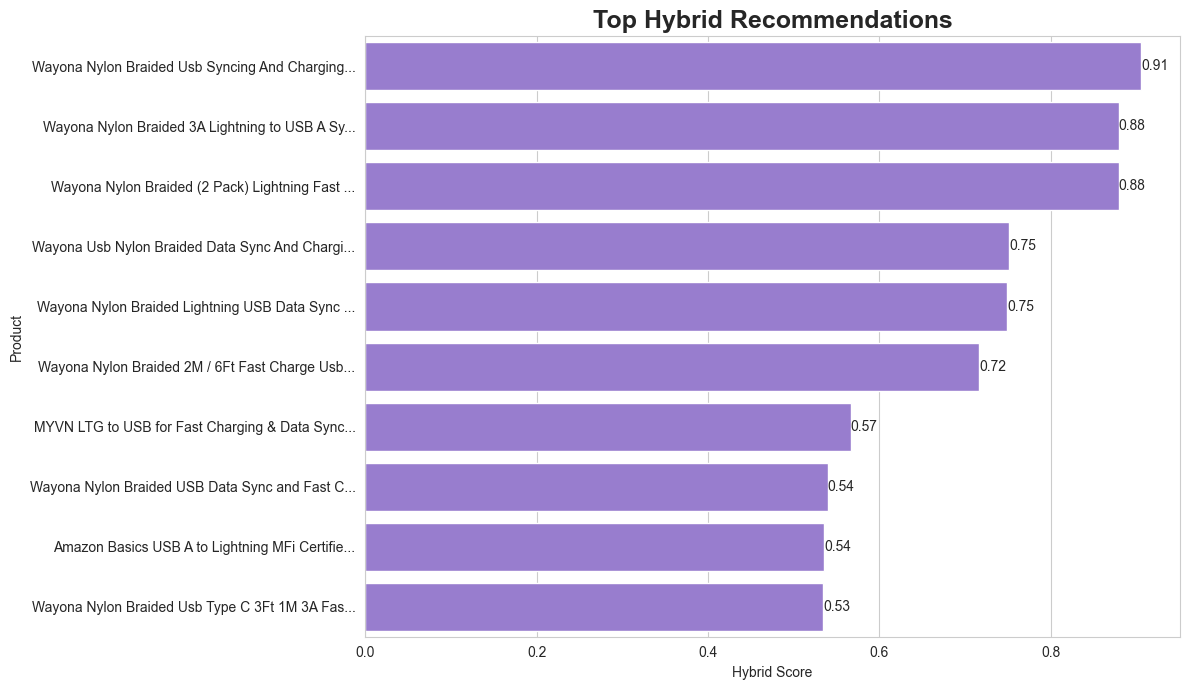

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=sample,
    x='hybrid_score',
    y='short_name',
    color='mediumpurple'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f'
    )

plt.title(
    "Top Hybrid Recommendations",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Hybrid Score")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [19]:
recommendation_df.to_csv(
    "../data/recommendation_dataset.csv",
    index=False
)